# Tarang ECG Classifier v7 — Single Model (Cascade Killed)

**Why this exists:** v5/v6's Gate→SV two-model cascade was diagnosed as structurally
broken across three independent runs (Phase A, Phase B, v5) — confirmed by confusion
matrices showing 5–35% S recall depending on Gate threshold. The failure is not
tunable away: a strict Gate deletes real S/V beats before the second model ever
sees them; a loose Gate floods the second model with Normal beats it has no way
to reject (binary S-vs-V has no "neither" option). Either threshold regime breaks
something. Full diagnostic trail in conversation history.

**The fix:** one 3-class softmax model. No filtering stage. Every beat gets full
gradient signal from all three classes, every time.

**What's kept from v5/v6** (all of it was good engineering, none of it is the problem):
- 250Hz / 130-sample window — verified against firmware (`app.c`:
  `TARANG_ECG_SAMPLE_RATE_HZ=250`, `LETIMER_TOP_VALUE=130`)
- 7 RR features incl. `compensatory_ratio` (PVC compensatory pause) and
  `prematurity_index` (SVEb prematurity) — both are named clinical signs, not
  arbitrary engineering
- SVDB for S-class data augmentation (train-only, never in test)
- INCART cross-database evaluation if available locally — auto-detected, used as a
  fully held-out generalization check (never trained on). This is the difference
  between "works on MIT-BIH" and "works on a different hospital's equipment,"
  which matters if this is meant for real clinical deployment.
- LR warmup + cosine decay, macro-F1 checkpointing (both already proven stable)

**What's new:**
- Single model, single threshold-tuning pass
- Threshold priority is explicit and clinical, not a blind macro-F1 grid search:
  1. V (PVC) threshold tuned first to guarantee recall ≥ 0.90 — missing a PVC is
     the worst clinical outcome, this is non-negotiable
  2. S threshold tuned second, maximizing S F1 *given* the V floor is already met
  3. Every class's F1 reported individually — no hiding S behind an aggregate
     "Abnormal" recall the way the Gate did


In [1]:
import os
import json
import subprocess
import warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample_poly

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")

# ── PATHS — edit if yours differ ──────────────────────────────────────────────
MITBIH_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0'
SVDB_PATH   = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-supraventricular-arrhythmia-database-1.0.0'
INCART_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/incartdb'

OUTPUTS_DIR      = 'outputs_v7_single'
MODEL_CHECKPOINT = f'{OUTPUTS_DIR}/tarang_single_best.keras'
TFLITE_PATH      = f'{OUTPUTS_DIR}/tarang_single_int8.tflite'
HEADER_PATH      = f'{OUTPUTS_DIR}/tarang_model.h'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── SAMPLING / WINDOW — MUST match firmware exactly ───────────────────────────
# app.c: TARANG_ECG_SAMPLE_RATE_HZ = 250, LETIMER_TOP_VALUE = 130
SOURCE_FS  = 360   # MIT-BIH / SVDB / INCART native rate
TARGET_FS  = 250   # firmware rate — non-negotiable, matches LDMA/IADC config
WINDOW_LEN = 130   # samples per beat — matches LETIMER_TOP_VALUE
WINDOW_PRE  = 65
WINDOW_POST = 65

INCART_AVAILABLE = os.path.isdir(INCART_PATH)

print("TensorFlow :", tf.__version__)
print("WFDB       :", wfdb.__version__)
print(f"Target FS  : {TARGET_FS} Hz (resample from {SOURCE_FS} Hz)")
print(f"Window     : {WINDOW_LEN} samples = {WINDOW_LEN/TARGET_FS*1000:.1f} ms")
print(f"MIT-BIH    : {MITBIH_PATH}")
print(f"SVDB       : {SVDB_PATH}  (exists={os.path.isdir(SVDB_PATH)})")
print(f"INCART     : {INCART_PATH}  (exists={INCART_AVAILABLE})")
print(f"Outputs    : {OUTPUTS_DIR}/")


GPU memory growth enabled for 1 GPU(s)
TensorFlow : 2.10.1
WFDB       : 4.1.2
Target FS  : 250 Hz (resample from 360 Hz)
Window     : 130 samples = 520.0 ms
MIT-BIH    : C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0
SVDB       : C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-supraventricular-arrhythmia-database-1.0.0  (exists=True)
INCART     : C:/MMD Public/Hackathons/Team Ocelleon/dataset/incartdb  (exists=True)
Outputs    : outputs_v7_single/


In [2]:
# AAMI/ANSI EC57 beat mapping — clinical standard, do not modify
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V', 'F': 'V',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}
CLASSES_TO_USE = ['N', 'V', 'S']

MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]

# Patient-wise split — same as v5/v6, proven, no leakage
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS   = [105, 124, 214, 220]
MITBIH_TRAIN_RECORDS = [r for r in MITBIH_ALL_RECORDS
                        if r not in MITBIH_TEST_RECORDS and r not in MITBIH_VAL_RECORDS]

# SVDB — train-only S/V boost (single-lead, duplicate channel fallback)
SVDB_RECORDS = [str(i) for i in range(800, 895)]

# INCART — fully held out, used only at final eval, never trained on
INCART_RECORDS = [f'I{i:02d}' for i in range(1, 76)] if INCART_AVAILABLE else []

print(f"MIT-BIH train : {len(MITBIH_TRAIN_RECORDS)} records")
print(f"MIT-BIH val   : {len(MITBIH_VAL_RECORDS)} records")
print(f"MIT-BIH test  : {len(MITBIH_TEST_RECORDS)} records (held out)")
print(f"SVDB train    : {len(SVDB_RECORDS)} records (S/V boost, train-only)")
print(f"INCART        : {len(INCART_RECORDS)} records "
      f"({'held-out cross-DB eval' if INCART_AVAILABLE else 'NOT FOUND — skipping cross-DB eval'})")


MIT-BIH train : 18 records
MIT-BIH val   : 4 records
MIT-BIH test  : 26 records (held out)
SVDB train    : 95 records (S/V boost, train-only)
INCART        : 75 records (held-out cross-DB eval)


In [3]:
def rolling_window_normalize(signal, fs, window_seconds=30):
    """Simulates firmware Welford rolling normalization (30s window)."""
    window_samples = int(window_seconds * fs)
    s    = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=window_samples, min_periods=1)
    mean = roll.mean()
    std  = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)


def compute_rr_features(peaks_sec, beat_idx):
    """
    7 RR-interval / rhythm features for one beat. All timing in SECONDS
    (sample-rate independent — safe across MIT-BIH/SVDB/INCART regardless of
    native fs, since peaks_sec is already converted to seconds before calling).

    peaks_sec : full sorted R-peak times (seconds) for this record
    beat_idx  : index of current beat in peaks_sec[]

    Returns float32 (7,):
      [0] rr_prev             — seconds since previous beat
      [1] rr_next             — seconds until next beat
      [2] rr_ratio            — rr_prev / rr_next (early-beat signature)
      [3] rr_mean_5           — mean of local 5-beat RR window
      [4] rr_std_5            — std of local 5-beat RR window (irregularity)
      [5] compensatory_ratio  — rr_next / rr_mean_5 — PVC compensatory pause
                                  is a NAMED clinical sign: PVC>~1.8, SVE<~1.5
      [6] prematurity_index   — rr_prev / rr_mean_5 — <0.85 signals an
                                  ectopic (premature) beat; this is the actual
                                  clinical definition of "premature"
    """
    n = len(peaks_sec)
    i = beat_idx
    prev_idx = max(0, i - 1)
    next_idx = min(n - 1, i + 1)

    rr_prev = peaks_sec[i] - peaks_sec[prev_idx]
    rr_next = peaks_sec[next_idx] - peaks_sec[i]
    rr_ratio = rr_prev / max(rr_next, 1e-4)

    lo, hi = max(0, i - 2), min(n - 1, i + 2)
    local_rrs = np.diff(peaks_sec[lo:hi+1]).astype(np.float32)
    if len(local_rrs) == 0:
        rr_mean_5, rr_std_5 = rr_prev, 0.0
    else:
        rr_mean_5 = float(np.mean(local_rrs))
        rr_std_5  = float(np.std(local_rrs))

    compensatory_ratio = rr_next / max(rr_mean_5, 1e-4)
    prematurity_index  = rr_prev / max(rr_mean_5, 1e-4)

    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
                      compensatory_ratio, prematurity_index], dtype=np.float32)

RR_FEATURE_NAMES = ['rr_prev', 'rr_next', 'rr_ratio', 'rr_mean_5', 'rr_std_5',
                     'compensatory_ratio', 'prematurity_index']
print(f"RR feature vector: {len(RR_FEATURE_NAMES)} features")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  [{i}] {name}")


RR feature vector: 7 features
  [0] rr_prev
  [1] rr_next
  [2] rr_ratio
  [3] rr_mean_5
  [4] rr_std_5
  [5] compensatory_ratio
  [6] prematurity_index


In [4]:
def load_records(db_path, record_list, source_tag, two_channel=True, source_fs=SOURCE_FS):
    """
    Load beats from a list of records, resampling to TARGET_FS (250Hz) to match
    firmware exactly. Returns:
      beats     (N, WINDOW_LEN, 2)
      rr        (N, 7)
      labels    (N,)
      record_ids(N,)
    """
    all_beats, all_rr, all_labels, all_recs = [], [], [], []

    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')

            n_channels = record.p_signal.shape[1]

            # Resample 360Hz -> 250Hz BEFORE normalization (resample_poly is
            # exact-ratio: 250/360 = 25/36)
            sig0 = resample_poly(record.p_signal[:, 0], 25, 36)
            if two_channel and n_channels > 1:
                sig1 = resample_poly(record.p_signal[:, 1], 25, 36)
            else:
                sig1 = sig0  # single-lead source: duplicate channel

            ecg_ch0 = rolling_window_normalize(sig0, TARGET_FS)
            ecg_ch1 = rolling_window_normalize(sig1, TARGET_FS)

            # Resample peak locations into the new sample-rate timeline,
            # then convert to seconds (sample-rate independent for RR features)
            peaks_resampled = (annotation.sample.astype(np.float64) * 25 / 36).astype(int)
            peaks_sec_all   = peaks_resampled / TARGET_FS

            syms = annotation.symbol
            valid_idxs = [i for i, s in enumerate(syms) if BEAT_MAP.get(s, None) in CLASSES_TO_USE]

            beats_this = 0
            for idx in valid_idxs:
                peak   = peaks_resampled[idx]
                mapped = BEAT_MAP[syms[idx]]

                if peak - WINDOW_PRE < 0 or peak + WINDOW_POST >= len(ecg_ch0):
                    continue

                beat = np.stack([
                    ecg_ch0[peak - WINDOW_PRE : peak + WINDOW_POST],
                    ecg_ch1[peak - WINDOW_PRE : peak + WINDOW_POST],
                ], axis=-1).astype(np.float32)

                if np.any(np.isnan(beat)) or np.any(np.isinf(beat)):
                    continue

                rr = compute_rr_features(peaks_sec_all, idx)

                all_beats.append(beat)
                all_rr.append(rr)
                all_labels.append(mapped)
                all_recs.append(f'{source_tag}_{rec_str}')
                beats_this += 1

            ch_tag = f'{n_channels}ch' + (' [DUP]' if n_channels == 1 else '')
            print(f"  {source_tag}/{rec_str}: {beats_this} beats  ({ch_tag})")

        except Exception as ex:
            print(f"  {source_tag}/{rec_str}: FAILED — {ex}")

    return (
        np.array(all_beats,  dtype=np.float32),
        np.array(all_rr,     dtype=np.float32),
        np.array(all_labels, dtype=object),
        np.array(all_recs,   dtype=object),
    )

print("load_records() defined — resamples 360→250Hz via resample_poly(25,36)")


load_records() defined — resamples 360→250Hz via resample_poly(25,36)


In [5]:
print("Loading MIT-BIH Arrhythmia Database (all records, 360->250 Hz)...")
mb_beats, mb_rr, mb_labels, mb_recs = load_records(
    MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True
)
print(f"\nMIT-BIH total: {mb_beats.shape}  classes={Counter(mb_labels)}")


Loading MIT-BIH Arrhythmia Database (all records, 360->250 Hz)...
  mitbih/100: 2271 beats  (2ch)
  mitbih/101: 1862 beats  (2ch)
  mitbih/102: 103 beats  (2ch)
  mitbih/103: 2084 beats  (2ch)
  mitbih/104: 165 beats  (2ch)
  mitbih/105: 2567 beats  (2ch)
  mitbih/106: 2027 beats  (2ch)
  mitbih/107: 59 beats  (2ch)
  mitbih/108: 1762 beats  (2ch)
  mitbih/109: 2531 beats  (2ch)
  mitbih/111: 2124 beats  (2ch)
  mitbih/112: 2539 beats  (2ch)
  mitbih/113: 1794 beats  (2ch)
  mitbih/114: 1879 beats  (2ch)
  mitbih/115: 1952 beats  (2ch)
  mitbih/116: 2411 beats  (2ch)
  mitbih/117: 1534 beats  (2ch)
  mitbih/118: 2277 beats  (2ch)
  mitbih/119: 1987 beats  (2ch)
  mitbih/121: 1863 beats  (2ch)
  mitbih/122: 2475 beats  (2ch)
  mitbih/123: 1517 beats  (2ch)
  mitbih/124: 1619 beats  (2ch)
  mitbih/200: 2600 beats  (2ch)
  mitbih/201: 1963 beats  (2ch)
  mitbih/202: 2136 beats  (2ch)
  mitbih/203: 2976 beats  (2ch)
  mitbih/205: 2656 beats  (2ch)
  mitbih/207: 1859 beats  (2ch)
  mitbih/2

In [6]:
print("Loading SVDB (Supraventricular Arrhythmia DB, S+V boost, train-only)...")
svdb_ok = os.path.isdir(SVDB_PATH)

if svdb_ok:
    sv_beats, sv_rr, sv_labels, sv_recs = load_records(
        SVDB_PATH, SVDB_RECORDS, 'svdb', two_channel=True
    )
    # SVDB is train-only by construction: keep S and V (boost minority classes),
    # drop Normal beats from SVDB to avoid diluting MIT-BIH's better-characterized N
    keep_mask = sv_labels != 'N'
    sv_beats, sv_rr, sv_labels, sv_recs = (
        sv_beats[keep_mask], sv_rr[keep_mask], sv_labels[keep_mask], sv_recs[keep_mask]
    )
    print(f"\nSVDB loaded (S+V only): {sv_beats.shape}  classes={Counter(sv_labels)}")
else:
    print(f"\nWARNING: SVDB not found at {SVDB_PATH} — proceeding MIT-BIH only.")
    sv_beats  = np.empty((0, WINDOW_LEN, 2), dtype=np.float32)
    sv_rr     = np.empty((0, 7),             dtype=np.float32)
    sv_labels = np.array([], dtype=object)
    sv_recs   = np.array([], dtype=object)


Loading SVDB (Supraventricular Arrhythmia DB, S+V boost, train-only)...
  svdb/800: 1883 beats  (2ch)
  svdb/801: 2507 beats  (2ch)
  svdb/802: 1670 beats  (2ch)
  svdb/803: 2068 beats  (2ch)
  svdb/804: 2832 beats  (2ch)
  svdb/805: 2296 beats  (2ch)
  svdb/806: 3020 beats  (2ch)
  svdb/807: 1940 beats  (2ch)
  svdb/808: 1774 beats  (2ch)
  svdb/809: 2542 beats  (2ch)
  svdb/810: 1902 beats  (2ch)
  svdb/811: 1434 beats  (2ch)
  svdb/812: 1842 beats  (2ch)
  svdb/813: FAILED — [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\813.hea'
  svdb/814: FAILED — [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\814.hea'
  svdb/815: FAILED — [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\815.hea'
  svdb/816: FAILED — [

Label encoding:
  0 = N
  1 = S
  2 = V

X shape    : (123579, 130, 2)
X_rr shape : (123579, 7)

Train: 56,620  Counter({'N': 31124, 'S': 13889, 'V': 11607})
Val  : 8,492   Counter({'N': 8017, 'V': 350, 'S': 125})
Test : 58,467  Counter({'N': 51466, 'V': 6040, 'S': 961})  <- MIT-BIH patient-wise, held out


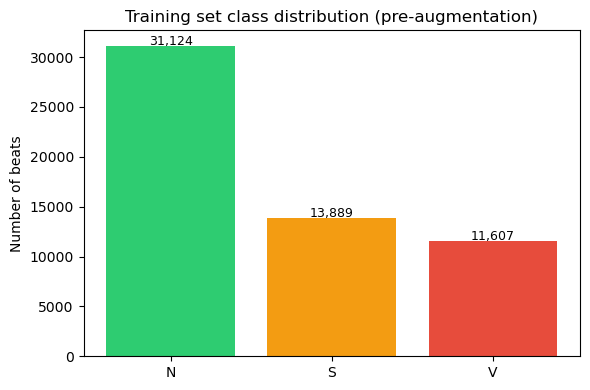

In [7]:
X_all     = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all  = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all = np.concatenate([mb_labels, sv_labels])
recs_all  = np.concatenate([mb_recs,   sv_recs])

le = LabelEncoder()
y_all = le.fit_transform(y_raw_all)
print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

test_mask  = np.array([r.startswith('mitbih_') and int(r.split('_')[1]) in MITBIH_TEST_RECORDS
                        for r in recs_all])
val_mask   = np.array([r.startswith('mitbih_') and int(r.split('_')[1]) in MITBIH_VAL_RECORDS
                        for r in recs_all])
train_mask = ~test_mask & ~val_mask   # MIT-BIH train + all SVDB

X_train,    X_val,    X_test    = X_all[train_mask],    X_all[val_mask],    X_all[test_mask]
X_rr_train, X_rr_val, X_rr_test = X_rr_all[train_mask], X_rr_all[val_mask], X_rr_all[test_mask]
y_train,    y_val,    y_test    = y_all[train_mask],    y_all[val_mask],    y_all[test_mask]

print(f"\nX shape    : {X_all.shape}")
print(f"X_rr shape : {X_rr_all.shape}")
print(f"\nTrain: {len(X_train):,}  {Counter(le.inverse_transform(y_train))}")
print(f"Val  : {len(X_val):,}   {Counter(le.inverse_transform(y_val))}")
print(f"Test : {len(X_test):,}  {Counter(le.inverse_transform(y_test))}  <- MIT-BIH patient-wise, held out")

fig, ax = plt.subplots(figsize=(6, 4))
classes_list = list(le.classes_)
train_counter = Counter(le.inverse_transform(y_train))
counts = [train_counter.get(c, 0) for c in classes_list]
ax.bar(classes_list, counts, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_title('Training set class distribution (pre-augmentation)')
ax.set_ylabel('Number of beats')
for i, v in enumerate(counts):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/class_distribution.png', dpi=100)
plt.show()


In [8]:
# Compute RR normalization from CLEAN (non-augmented) training data only.
# Firmware must replicate this exact mean/std.
RR_MEAN = X_rr_train.mean(axis=0)
RR_STD  = X_rr_train.std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8

print("RR normalization stats (hardcode these in firmware as RR_MEAN_xxx/RR_STD_xxx):")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  [{i}] {name:<20}: mean={RR_MEAN[i]:.5f}  std={RR_STD[i]:.5f}")

X_rr_train_norm = (X_rr_train - RR_MEAN) / RR_STD
X_rr_val_norm   = (X_rr_val   - RR_MEAN) / RR_STD
X_rr_test_norm  = (X_rr_test  - RR_MEAN) / RR_STD


RR normalization stats (hardcode these in firmware as RR_MEAN_xxx/RR_STD_xxx):
  [0] rr_prev             : mean=0.54806  std=0.35746
  [1] rr_next             : mean=0.58537  std=0.32677
  [2] rr_ratio            : mean=2.29891  std=99.15727
  [3] rr_mean_5           : mean=0.56795  std=0.31752
  [4] rr_std_5            : mean=0.06000  std=0.10305
  [5] compensatory_ratio  : mean=1.05885  std=0.20276
  [6] prematurity_index   : mean=0.92194  std=0.19120


In [9]:
def augment_batch(X_c, X_rr_c, class_name, n_copies):
    """
    Augment ECG waveform + RR features together, consistently.
    S: simulate prematurity (shorter rr_prev, lower prematurity_index, higher rr_std)
    V: simulate compensatory pause (longer rr_next, higher compensatory_ratio)
    """
    n = len(X_c)
    ecg_list, rr_list = [], []

    for _ in range(n_copies):
        a = X_c.copy()

        scale = np.random.uniform(0.85, 1.15, (n, 1, 1))
        a *= scale

        t_arr  = np.linspace(0, 2*np.pi, WINDOW_LEN)
        freqs  = np.random.uniform(0.3, 0.8, n)
        amps   = np.random.uniform(0.0, 0.12, n)
        wander = (amps[:, None] * np.sin(freqs[:, None] * t_arr[None, :]))[:, :, None]
        a += wander

        a += np.random.normal(0, np.random.uniform(0.01, 0.04), a.shape).astype(np.float32)

        shifts = np.random.randint(-6, 7, n)   # smaller window (130) -> smaller shift
        for i in range(n):
            a[i] = np.roll(a[i], shifts[i], axis=0)

        if class_name == 'S':
            a[:, :28, :] *= np.random.uniform(0.4, 1.6, (n, 1, 1))  # P-wave region

        ecg_list.append(a.astype(np.float32))

        rr = X_rr_c.copy()
        if class_name == 'S':
            rr[:, 0] *= np.random.uniform(0.6, 0.95, n)              # rr_prev shorter
            rr[:, 2]  = rr[:, 0] / np.maximum(rr[:, 1], 1e-4)        # recompute ratio
            rr[:, 4] *= np.random.uniform(1.1, 1.5, n)               # rr_std_5 higher
            rr[:, 6]  = rr[:, 0] / np.maximum(rr[:, 3], 1e-4)        # recompute prematurity_index
        elif class_name == 'V':
            rr[:, 1] *= np.random.uniform(1.05, 1.25, n)             # rr_next longer (compensatory pause)
            rr[:, 5]  = rr[:, 1] / np.maximum(rr[:, 3], 1e-4)        # recompute compensatory_ratio
            rr[:, 4] *= np.random.uniform(1.0, 1.3, n)

        rr *= np.random.uniform(0.95, 1.05, rr.shape)
        rr  = np.clip(rr, -1.0, 5.0).astype(np.float32)
        rr_list.append(rr)

    return np.concatenate(ecg_list, axis=0), np.concatenate(rr_list, axis=0)


# N: no augmentation (majority). V: 5x extra. S: 10x extra (hardest, weakest class).
AUG_COPIES = {'N': 0, 'V': 5, 'S': 10}
print(f"Augmentation plan: {AUG_COPIES}")


Augmentation plan: {'N': 0, 'V': 5, 'S': 10}


In [10]:
print("Augmenting minority classes...")
ecg_list = [X_train]
rr_list  = [X_rr_train_norm]
y_list   = [y_train]

for class_idx, class_name in enumerate(le.classes_):
    n_copies = AUG_COPIES.get(class_name, 0)
    if n_copies == 0:
        continue
    mask = y_train == class_idx
    # augment on RAW (unnormalized) RR, then normalize after — keeps augmentation
    # math (ratios, etc.) in physically meaningful units
    aug_ecg, aug_rr_raw = augment_batch(X_train[mask], X_rr_train[mask], class_name, n_copies)
    aug_rr_norm = (aug_rr_raw - RR_MEAN) / RR_STD
    ecg_list.append(aug_ecg)
    rr_list.append(aug_rr_norm.astype(np.float32))
    y_list.append(np.tile(y_train[mask], n_copies))

X_train_aug    = np.concatenate(ecg_list, axis=0)
X_rr_train_aug = np.concatenate(rr_list,  axis=0)
y_train_aug    = np.concatenate(y_list,   axis=0)

idx = np.random.permutation(len(X_train_aug))
X_train_aug    = X_train_aug[idx]
X_rr_train_aug = X_rr_train_aug[idx]
y_train_aug    = y_train_aug[idx]

print(f"Before aug : {Counter(le.inverse_transform(y_train))}")
print(f"After aug  : {Counter(le.inverse_transform(y_train_aug))}")
print(f"Total beats: {len(X_train_aug):,}")
print(f"ECG shape  : {X_train_aug.shape}")
print(f"RR shape   : {X_rr_train_aug.shape}")


Augmenting minority classes...
Before aug : Counter({'N': 31124, 'S': 13889, 'V': 11607})
After aug  : Counter({'S': 152779, 'V': 69642, 'N': 31124})
Total beats: 253,545
ECG shape  : (253545, 130, 2)
RR shape   : (253545, 7)


In [11]:
def build_tarang_single(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,), num_classes=3):
    """
    ONE model. ECG branch (depthwise-separable CNN) + RR branch (dense) -> concat
    -> softmax(N, S, V). No Gate, no cascade, no filtering stage.
    """
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')

    x = tf.keras.layers.SeparableConv1D(16, 7, padding='same', use_bias=False,
            depthwise_regularizer=regularizers.l2(1e-4))(ecg_in)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.SeparableConv1D(32, 5, padding='same', use_bias=False,
            depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.SeparableConv1D(64, 5, padding='same', use_bias=False,
            depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout1D(0.15)(x)

    x = tf.keras.layers.SeparableConv1D(64, 3, padding='same', use_bias=False,
            depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='predictions')(merged)

    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=outputs, name='Tarang_Single')


model = build_tarang_single(num_classes=len(le.classes_))
model.summary()

total_params = model.count_params()
print(f"\nParameters: {total_params:,}")
print(f"Est. INT8 : ~{total_params/1024:.1f} KB  "
      f"({'PASS' if total_params < 51200 else 'OVER 50KB — reduce capacity'})")


Model: "Tarang_Single"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 separable_conv1d (SeparableCon  (None, 130, 16)     46          ['ecg_input[0][0]']              
 v1D)                                                                                             
                                                                                                  
 batch_normalization (BatchNorm  (None, 130, 16)     64          ['separable_conv1d[0][0]']       
 alization)                                                                                       
                                                                                      

In [12]:
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = tf.constant(alpha, dtype=tf.float32)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_onehot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        cross_entropy = -y_onehot * tf.math.log(y_pred)
        pt = tf.reduce_sum(y_onehot * y_pred, axis=-1)
        focal_weight = tf.pow(1.0 - pt, self.gamma)
        alpha_weight = tf.reduce_sum(self.alpha * y_onehot, axis=-1)
        loss = alpha_weight * focal_weight * tf.reduce_sum(cross_entropy, axis=-1)
        return tf.reduce_mean(loss)


class MacroF1Callback(tf.keras.callbacks.Callback):
    """Checkpoints on macro F1, not val_loss — val_loss is dominated by the
    majority N class and gives a misleading 'best' epoch for minority classes."""
    def __init__(self, val_data, filepath):
        super().__init__()
        self.X_val, self.y_val = val_data
        self.filepath = filepath
        self.best = -1.0

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.X_val, batch_size=256, verbose=0)
        preds = np.argmax(probs, axis=1)
        macro_f1 = f1_score(self.y_val, preds, average='macro', zero_division=0)
        logs = logs or {}
        logs['val_macro_f1'] = macro_f1
        if macro_f1 > self.best:
            self.best = macro_f1
            self.model.save(self.filepath)
            print(f"\nEpoch {epoch+1}: val_macro_f1 improved to {macro_f1:.5f}, saving model")


# Label order is alphabetical from LabelEncoder: N, S, V
# alpha: N downweighted (majority + easy), S upweighted (hardest), V moderate
# (this is the v3-proven config — NOT the v5/v6 cascade alphas, which drifted)
focal_alpha = [0.15, 0.50, 0.35]
focal_gamma = 2.0
print(f"Focal loss: alpha={focal_alpha} (order: {list(le.classes_)}), gamma={focal_gamma}")

EPOCHS = 60
WARMUP_EPOCHS = 2
BASE_LR = 5e-4

def lr_schedule(epoch):
    if epoch < WARMUP_EPOCHS:
        return BASE_LR * (epoch + 1) / WARMUP_EPOCHS / 2
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 1e-6 + 0.5 * (BASE_LR - 1e-6) * (1 + np.cos(np.pi * progress))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BASE_LR, clipnorm=1.0),
    loss=SparseFocalLoss(alpha=focal_alpha, gamma=focal_gamma),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
    tf.keras.callbacks.EarlyStopping(monitor='loss', patience=15, restore_best_weights=False, verbose=1),
    MacroF1Callback(val_data=([X_val, X_rr_val_norm], y_val), filepath=MODEL_CHECKPOINT),
]

history = model.fit(
    [X_train_aug, X_rr_train_aug], y_train_aug,
    validation_data=([X_val, X_rr_val_norm], y_val),
    epochs=EPOCHS,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

history_clean = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(f'{OUTPUTS_DIR}/training_history.json', 'w') as f:
    json.dump(history_clean, f)


Focal loss: alpha=[0.15, 0.5, 0.35] (order: ['N', 'S', 'V']), gamma=2.0
Epoch 1/60
7923/7924 [============================>.] - ETA: 0s - loss: 0.0685 - accuracy: 0.8082
Epoch 1: val_macro_f1 improved to 0.60202, saving model
7924/7924 [==============================] - 136s 16ms/step - loss: 0.0685 - accuracy: 0.8082 - val_loss: 0.0286 - val_accuracy: 0.9379 - lr: 1.2500e-04 - val_macro_f1: 0.6020
Epoch 2/60
7924/7924 [==============================] - ETA: 0s - loss: 0.0273 - accuracy: 0.9159
Epoch 2: val_macro_f1 improved to 0.60346, saving model
7924/7924 [==============================] - 128s 16ms/step - loss: 0.0273 - accuracy: 0.9159 - val_loss: 0.0274 - val_accuracy: 0.9316 - lr: 2.5000e-04 - val_macro_f1: 0.6035
Epoch 3/60
7924/7924 [==============================] - 130s 16ms/step - loss: 0.0202 - accuracy: 0.9394 - val_loss: 0.0258 - val_accuracy: 0.9370 - lr: 5.0000e-04 - val_macro_f1: 0.6023
Epoch 4/60
7923/7924 [============================>.] - ETA: 0s - loss: 0.0169 - 

In [13]:
print('='*60)
print('THRESHOLD TUNING — V (PVC) safety floor FIRST, S maximized second')
print('='*60)

model = tf.keras.models.load_model(
    MODEL_CHECKPOINT, custom_objects={'SparseFocalLoss': SparseFocalLoss}, compile=False
)

y_val_probs = model.predict([X_val, X_rr_val_norm], batch_size=256)

n_idx = int(np.where(le.classes_ == 'N')[0])
s_idx = int(np.where(le.classes_ == 'S')[0])
v_idx = int(np.where(le.classes_ == 'V')[0])

V_RECALL_FLOOR = 0.90   # clinical non-negotiable: missing a PVC is the worst outcome

# STEP 1: find the highest V threshold that still clears the recall floor
# (highest threshold = fewest false V alarms, while still catching >=90% of real V)
best_v_thresh = 0.10
for t_v in np.arange(0.50, 0.05, -0.01):
    v_pred = y_val_probs[:, v_idx] > t_v
    v_recall = np.sum((y_val == v_idx) & v_pred) / max(np.sum(y_val == v_idx), 1)
    if v_recall >= V_RECALL_FLOOR:
        best_v_thresh = round(t_v, 2)
        break

# STEP 2: GIVEN that V threshold is fixed, search S threshold to maximize S F1
best_s_thresh = 0.5
best_s_f1 = 0.0
for t_s in np.arange(0.05, 0.70, 0.01):
    y_pred = np.full(len(y_val), n_idx, dtype=int)
    y_pred[y_val_probs[:, s_idx] > t_s] = s_idx
    y_pred[y_val_probs[:, v_idx] > best_v_thresh] = v_idx   # V overrides S — V wins ties
    s_f1 = f1_score(y_val == s_idx, y_pred == s_idx, zero_division=0)
    if s_f1 > best_s_f1:
        best_s_f1 = s_f1
        best_s_thresh = round(t_s, 2)

best_thresholds = {'S': best_s_thresh, 'V': best_v_thresh}

# Verify on val
y_pred_val = np.full(len(y_val), n_idx, dtype=int)
y_pred_val[y_val_probs[:, s_idx] > best_thresholds['S']] = s_idx
y_pred_val[y_val_probs[:, v_idx] > best_thresholds['V']] = v_idx
v_recall_val = np.sum((y_val == v_idx) & (y_pred_val == v_idx)) / max(np.sum(y_val == v_idx), 1)

print(f"V threshold: {best_thresholds['V']}  (val V recall = {v_recall_val:.3f}, floor = {V_RECALL_FLOOR})")
print(f"S threshold: {best_thresholds['S']}  (val S F1 = {best_s_f1:.3f})")

# ── Evaluate on held-out MIT-BIH test ────────────────────────────────────────
print('\n' + '='*60)
print('MIT-BIH TEST SET — held out, patient-wise')
print('='*60)

y_pred_probs = model.predict([X_test, X_rr_test_norm], batch_size=256)
y_pred_test  = np.full(len(y_test), n_idx, dtype=int)
y_pred_test[y_pred_probs[:, s_idx] > best_thresholds['S']] = s_idx
y_pred_test[y_pred_probs[:, v_idx] > best_thresholds['V']] = v_idx

print(classification_report(y_test, y_pred_test, target_names=le.classes_))

f1_per_class = f1_score(y_test, y_pred_test, average=None, zero_division=0)
macro_f1     = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
v_recall_test = np.sum((y_test == v_idx) & (y_pred_test == v_idx)) / max(np.sum(y_test == v_idx), 1)

print(f"Macro F1: {macro_f1:.3f}")
print(f"V recall (clinical floor check): {v_recall_test:.3f}  "
      f"[{'PASS' if v_recall_test >= V_RECALL_FLOOR else 'BELOW FLOOR — revisit threshold'}]")
for cls, f1 in zip(le.classes_, f1_per_class):
    print(f"  F1 {cls}: {f1:.3f}")


THRESHOLD TUNING — V (PVC) safety floor FIRST, S maximized second
34/34 [==============================] - 0s 2ms/step
V threshold: 0.12  (val V recall = 0.900, floor = 0.9)
S threshold: 0.29  (val S F1 = 0.583)

MIT-BIH TEST SET — held out, patient-wise
229/229 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           N       0.99      0.67      0.80     51466
           S       0.13      0.25      0.18       961
           V       0.26      0.94      0.41      6040

    accuracy                           0.69     58467
   macro avg       0.46      0.62      0.46     58467
weighted avg       0.90      0.69      0.75     58467

Macro F1: 0.462
V recall (clinical floor check): 0.944  [PASS]
  F1 N: 0.799
  F1 S: 0.175
  F1 V: 0.411


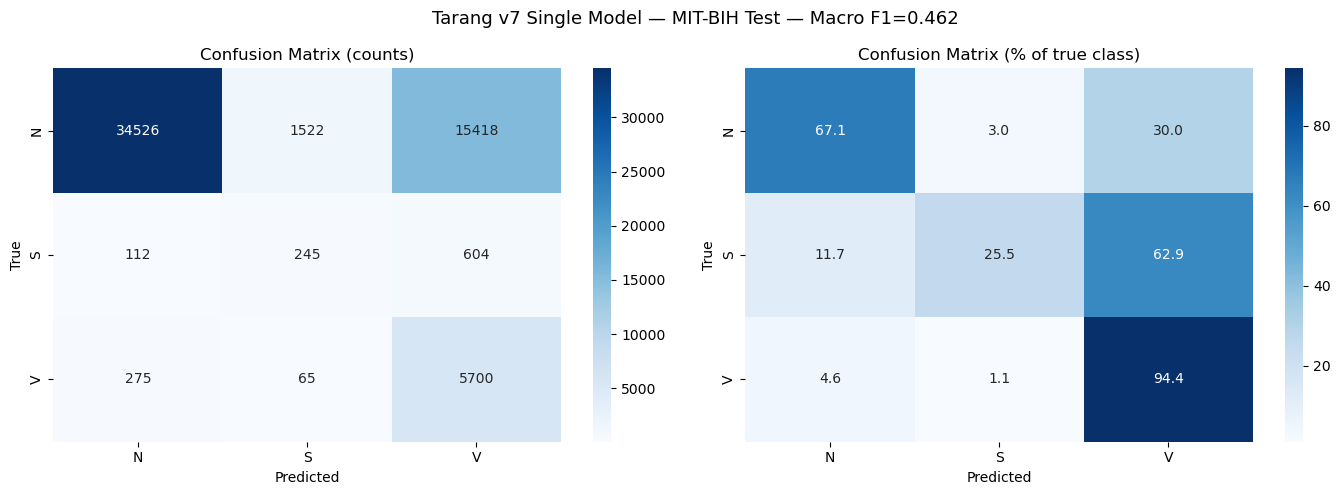

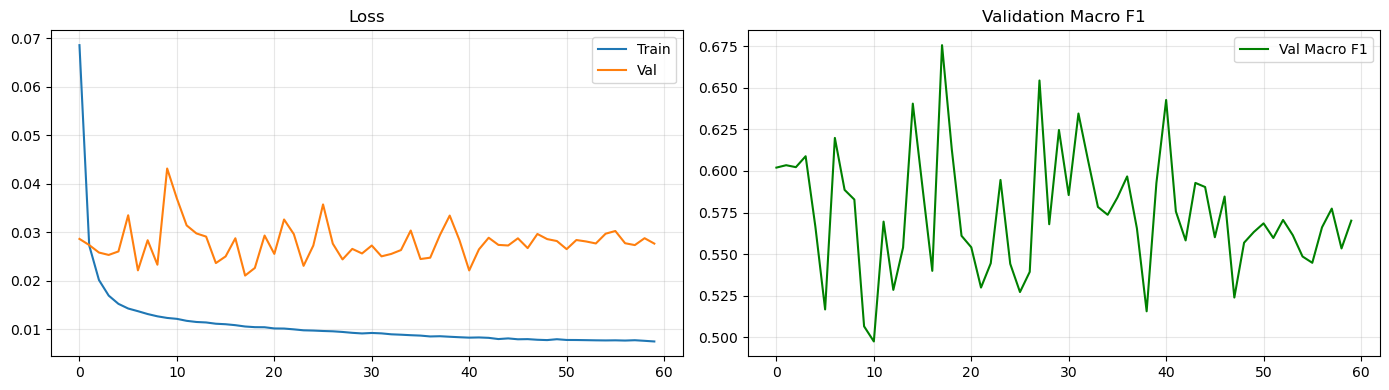

In [14]:
cm = confusion_matrix(y_test, y_pred_test)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (% of true class)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.suptitle(f'Tarang v7 Single Model — MIT-BIH Test — Macro F1={macro_f1:.3f}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='Train')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
if 'val_macro_f1' in history.history:
    axes[1].plot(history.history['val_macro_f1'], label='Val Macro F1', color='green')
    axes[1].set_title('Validation Macro F1'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
print('='*60)
print('CROSS-DATABASE EVALUATION — INCART (held out, never trained)')
print('='*60)

if INCART_AVAILABLE:
    incart_beats, incart_rr, incart_labels, incart_recs = load_records(
        INCART_PATH, INCART_RECORDS, 'incart', two_channel=True
    )
    incart_y = le.transform(incart_labels)
    incart_rr_norm = (incart_rr - RR_MEAN) / RR_STD

    incart_probs = model.predict([incart_beats, incart_rr_norm], batch_size=256)
    incart_pred  = np.full(len(incart_y), n_idx, dtype=int)
    incart_pred[incart_probs[:, s_idx] > best_thresholds['S']] = s_idx
    incart_pred[incart_probs[:, v_idx] > best_thresholds['V']] = v_idx

    print(f"\nINCART: {len(incart_beats):,} beats  {Counter(incart_labels)}")
    print(classification_report(incart_y, incart_pred, target_names=le.classes_, zero_division=0))

    incart_macro_f1 = f1_score(incart_y, incart_pred, average='macro', zero_division=0)
    gap = macro_f1 - incart_macro_f1
    print(f"INCART macro F1: {incart_macro_f1:.3f}")
    print(f"Generalization gap (MIT-BIH - INCART): {gap:+.3f}")
    print(f"\n{'GOOD GENERALIZATION' if gap < 0.15 else 'NOTABLE GAP — model may be overfit to MIT-BIH electrode/population characteristics'}")
else:
    print(f"\nINCART not found at {INCART_PATH} — skipping cross-DB eval.")
    print("This is fine for the demo, but if you get INCART downloaded later,")
    print("rerun this cell alone (model + thresholds are already in memory).")


CROSS-DATABASE EVALUATION — INCART (held out, never trained)
  incart/I01: 2757 beats  (12ch)
  incart/I02: 2673 beats  (12ch)
  incart/I03: 2451 beats  (12ch)
  incart/I04: 2423 beats  (12ch)
  incart/I05: 1775 beats  (12ch)
  incart/I06: 2493 beats  (12ch)
  incart/I07: 2704 beats  (12ch)
  incart/I08: 2129 beats  (12ch)
  incart/I09: 2988 beats  (12ch)
  incart/I10: 3682 beats  (12ch)
  incart/I11: 2081 beats  (12ch)
  incart/I12: 2808 beats  (12ch)
  incart/I13: 2023 beats  (12ch)
  incart/I14: 1865 beats  (12ch)
  incart/I15: 2633 beats  (12ch)
  incart/I16: 1522 beats  (12ch)
  incart/I17: 1672 beats  (12ch)
  incart/I18: 3083 beats  (12ch)
  incart/I19: 2062 beats  (12ch)
  incart/I20: 2650 beats  (12ch)
  incart/I21: 2184 beats  (12ch)
  incart/I22: 3126 beats  (12ch)
  incart/I23: 2204 beats  (12ch)
  incart/I24: 2569 beats  (12ch)
  incart/I25: 1712 beats  (12ch)
  incart/I26: 1509 beats  (12ch)
  incart/I27: 2605 beats  (12ch)
  incart/I28: 1717 beats  (12ch)
  incart/I29: 2

In [16]:
CONFIDENCE_THRESHOLD = 0.70

model = tf.keras.models.load_model(
    MODEL_CHECKPOINT, custom_objects={'SparseFocalLoss': SparseFocalLoss}, compile=False
)

def representative_dataset():
    idx = np.random.choice(len(X_train), min(1000, len(X_train)), replace=False)
    for i in idx:
        ecg_sample = X_train[i:i+1].astype(np.float32)
        rr_sample  = X_rr_train_norm[i:i+1].astype(np.float32)
        yield [ecg_sample, rr_sample]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations             = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset    = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.int8
converter.inference_output_type     = tf.int8

print("Quantizing to INT8...")
tflite_model = converter.convert()
print("Done.")

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"\nINT8 model size: {size_kb:.1f} KB")
print(f"Target < 50 KB : {'PASS' if size_kb < 50 else 'FAIL — reduce capacity'}")

interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
input_details  = interp.get_input_details()
output_details = interp.get_output_details()

ecg_det = next(d for d in input_details if d['shape'][1] == WINDOW_LEN)
rr_det  = next(d for d in input_details if d['shape'][1] == 7)
out_det = output_details[0]

ecg_scale, ecg_zp = ecg_det['quantization']
rr_scale,  rr_zp  = rr_det['quantization']
out_scale, out_zp = out_det['quantization']

print(f"\nECG input quant: scale={ecg_scale:.6f}, zero_point={ecg_zp}")
print(f"RR  input quant: scale={rr_scale:.6f},  zero_point={rr_zp}")
print(f"Output    quant: scale={out_scale:.6f}, zero_point={out_zp}")

print("\n" + "="*55)
print("COPY THESE INTO FIRMWARE")
print("="*55)
print(f"#define ECG_INPUT_SCALE       {ecg_scale:.8f}f")
print(f"#define ECG_INPUT_ZERO_POINT  {ecg_zp}")
print(f"#define RR_INPUT_SCALE        {rr_scale:.8f}f")
print(f"#define RR_INPUT_ZERO_POINT   {rr_zp}")
print(f"#define OUTPUT_SCALE          {out_scale:.8f}f")
print(f"#define OUTPUT_ZERO_POINT     {out_zp}")
print(f"#define V_THRESHOLD_INT8      {int(round(best_thresholds['V'] / out_scale + out_zp))}")
print(f"#define S_THRESHOLD_INT8      {int(round(best_thresholds['S'] / out_scale + out_zp))}")
print(f"// RR normalization (apply BEFORE RR_INPUT_SCALE quantization)")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"#define RR_MEAN_{name.upper():<20} {RR_MEAN[i]:.6f}f")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"#define RR_STD_{name.upper():<21} {RR_STD[i]:.6f}f")


Quantizing to INT8...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp99swnx4f\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp99swnx4f\assets


RuntimeError: tensorflow/lite/kernels/depthwise_conv.cc:116 NumDimensions(input) != 4 (3 != 4)Node number 3 (DEPTHWISE_CONV_2D) failed to prepare.

In [ ]:
n = min(2000, len(X_test))
X_ecg_sample = X_test[:n]
X_rr_sample  = X_rr_test_norm[:n]
y_sample     = y_test[:n]

float_preds = np.argmax(model.predict([X_ecg_sample, X_rr_sample], batch_size=256, verbose=0), axis=1)
float_acc   = np.mean(float_preds == y_sample) * 100

correct_int8 = 0
for i in range(n):
    x_ecg_q = np.clip(np.round(X_ecg_sample[i:i+1] / ecg_scale + ecg_zp), -128, 127).astype(np.int8)
    x_rr_q  = np.clip(np.round(X_rr_sample[i:i+1]  / rr_scale  + rr_zp),  -128, 127).astype(np.int8)
    interp.set_tensor(ecg_det['index'], x_ecg_q)
    interp.set_tensor(rr_det['index'],  x_rr_q)
    interp.invoke()
    out_q = interp.get_tensor(out_det['index'])
    out_f = (out_q.astype(np.float32) - out_zp) * out_scale
    if np.argmax(out_f) == y_sample[i]:
        correct_int8 += 1

int8_acc = correct_int8 / n * 100
drop = float_acc - int8_acc
print(f"Float32 accuracy (n={n}): {float_acc:.2f}%")
print(f"INT8    accuracy (n={n}): {int8_acc:.2f}%")
print(f"Accuracy drop: {drop:.2f}%  [{'ACCEPTABLE' if drop < 3.0 else 'TOO HIGH — check normalization'}]")


In [ ]:
try:
    result = subprocess.run(['xxd', '-i', TFLITE_PATH], capture_output=True, text=True)
    xxd_ok = result.returncode == 0 and bool(result.stdout)
except FileNotFoundError:
    xxd_ok = False

if xxd_ok:
    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN v7 — single-model INT8 dual-input\n')
        f.write('// Auto-generated — do not edit\n\n#pragma once\n\n')
        f.write(result.stdout)
    print(f"Generated {HEADER_PATH}")
else:
    with open(TFLITE_PATH, 'rb') as f:
        data = f.read()
    hex_lines = ['  ' + ', '.join(f'0x{b:02x}' for b in data[i:i+12]) + ',' for i in range(0, len(data), 12)]
    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN v7 — single-model INT8 dual-input\n')
        f.write('// Auto-generated — do not edit\n\n#pragma once\n\n')
        f.write(f'#define TARANG_MODEL_LEN {len(data)}\n\n')
        f.write('alignas(8) const unsigned char tarang_int8_tflite[] = {\n')
        f.write('\n'.join(hex_lines))
        f.write('\n};\n')
    print(f"Generated {HEADER_PATH} ({len(data):,} bytes)")


In [ ]:
print('='*60)
print('PEAK JITTER ROBUSTNESS TEST')
print('='*60)

def evaluate_with_jitter(model, X_ecg, X_rr, y, jitter_std, thresholds):
    if jitter_std == 0:
        X_jit = X_ecg
    else:
        jitter = np.random.normal(0, jitter_std, len(X_ecg)).astype(int)
        X_jit = np.array([np.roll(X_ecg[i], jitter[i], axis=0) for i in range(len(X_ecg))])
    probs = model.predict([X_jit, X_rr], batch_size=256, verbose=0)
    preds = np.full(len(y), n_idx, dtype=int)
    preds[probs[:, s_idx] > thresholds['S']] = s_idx
    preds[probs[:, v_idx] > thresholds['V']] = v_idx
    return f1_score(y, preds, average='macro', zero_division=0)

for jitter in [0, 3, 5, 8, 10]:
    f1 = evaluate_with_jitter(model, X_test, X_rr_test_norm, y_test, jitter, best_thresholds)
    print(f"Jitter ±{jitter:2d} samples (~{jitter/TARGET_FS*1000:.0f}ms): Macro F1 = {f1:.3f}")


In [ ]:
print('='*60)
print('BLE EVENT-DRIVEN BURST FILTER (POST-PROCESSING)')
print('='*60)

def apply_run_filter(predictions, min_run=3, window=10):
    filtered = predictions.copy()
    for i in range(window, len(predictions)):
        window_preds = predictions[i-window:i]
        if np.sum(window_preds != n_idx) < min_run:
            filtered[i] = n_idx
    return filtered

y_pred_filtered = apply_run_filter(y_pred_test)
print("Raw tuned predictions:")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))
print("After BLE burst filter:")
print(classification_report(y_test, y_pred_filtered, target_names=le.classes_))


## Firmware Integration — `tarang_ai_process()`

Currently a stub in `app.c` (`(void)in; return;`). Single-model call is simpler
than the cascade would have been — one `Invoke()`, one model in flash.

```c
typedef struct {
    float rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5;
    float compensatory_ratio;   // rr_next / rr_mean_5 — PVC compensatory pause
    float prematurity_index;    // rr_prev / rr_mean_5 — SVEb prematurity
} tarang_rr_features_t;

typedef enum { TARANG_BEAT_NORMAL, TARANG_BEAT_SVEB, TARANG_BEAT_PVC } tarang_beat_label_t;

void tarang_ai_process(const tarang_ai_input_t *in)
{
    if ((in == NULL) || (in->frame == NULL)) return;

    // 1. Normalize RR features: x_norm = (x_raw - RR_MEAN_x) / RR_STD_x
    // 2. Quantize ECG window: x_q = clamp(round(x/ECG_INPUT_SCALE + ECG_INPUT_ZERO_POINT), -128, 127)
    // 3. Quantize RR features: same pattern with RR_INPUT_SCALE/ZERO_POINT
    // 4. interpreter->input(0) <- ecg_q ; interpreter->input(1) <- rr_q
    // 5. interpreter->Invoke()
    // 6. Dequantize output, apply V_THRESHOLD_INT8 first (checked first — V wins ties),
    //    then S_THRESHOLD_INT8
    // 7. Map TARANG_BEAT_PVC -> TARANG_ANOMALY_FLAG_PVC bit in BLE packet
    //    Map TARANG_BEAT_SVEB -> new flag bit (or repurpose AFIB flag — confirm with team)
}
```

V threshold is checked first and wins any tie with S — this matches the clinical
priority baked into the training: never silently let a PVC be relabeled as
something less urgent.
